In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# Load Worker Geospatial Matching Dataset

df = pd.read_csv(
    "../../datasets/worker_geospatial_matching_data.csv"
)

print("--- Worker Geospatial Matching Data ---")
print(f"Dataset Shape: {df.shape}")

print("\nData Types:")
print(df.dtypes)

display(df.head())

--- Worker Geospatial Matching Data ---
Dataset Shape: (2000, 8)

Data Types:
Worker_Experience_Years         int64
Worker_Primary_Skills          object
Job_Required_Skill             object
Distance_KM                   float64
Worker_Historical_Rating      float64
Farmer_Historical_Rating      float64
Historical_Acceptance_Rate    float64
Is_Successful_Match             int64
dtype: object


,Worker_Experience_Years,Worker_Primary_Skills,Job_Required_Skill,Distance_KM,Worker_Historical_Rating,Farmer_Historical_Rating,Historical_Acceptance_Rate,Is_Successful_Match
0,10,"Seeding, Pesticide Spraying",Pruning,33.98,4.1,3.9,0.66,0
1,1,"Pesticide Spraying, Harvesting, Seeding",Seeding,19.70,4.0,3.6,0.61,1
2,13,"Pruning, Tractor Driving, Pesticide Spraying",Harvesting,17.08,3.6,3.8,0.32,0
3,1,"Seeding, Harvesting",Harvesting,2.14,4.5,4.9,0.47,1
4,9,"Seeding, Pesticide Spraying, Harvesting",Pesticide Spraying,14.30,4.4,3.7,0.87,1


In [50]:
print(df['Is_Successful_Match'].value_counts())
print("\nPercentages:")
print(df['Is_Successful_Match'].value_counts(normalize=True) * 100)

Is_Successful_Match
0    1147
1     853
Name: count, dtype: int64

Percentages:
Is_Successful_Match
0    57.35
1    42.65
Name: proportion, dtype: float64


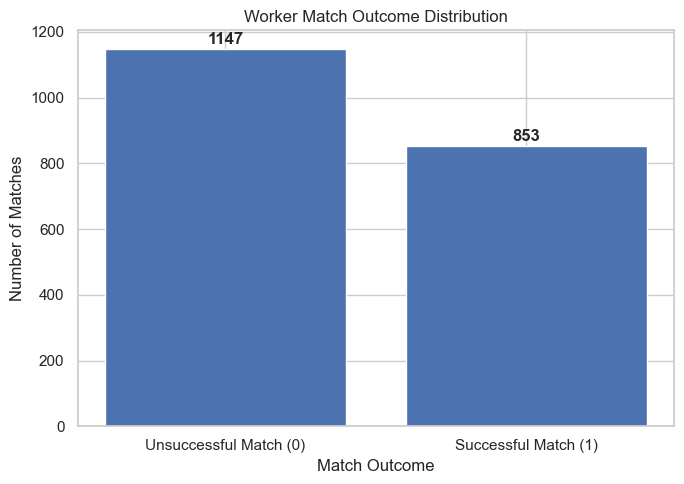

In [51]:
counts = df['Is_Successful_Match'].value_counts().sort_index()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ['Unsuccessful Match (0)', 'Successful Match (1)'],
    counts.values
)

plt.title('Worker Match Outcome Distribution')
plt.xlabel('Match Outcome')
plt.ylabel('Number of Matches')

# Add numbers on bars
for bar, value in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        str(value),
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

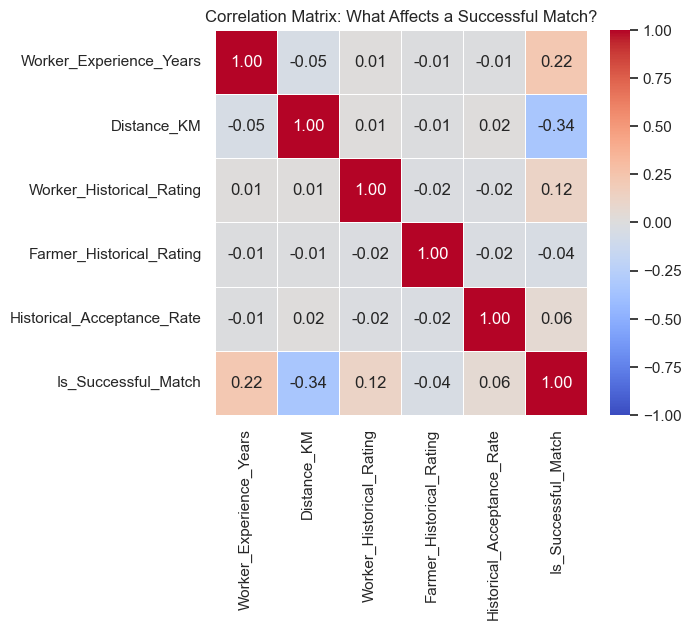

In [52]:
# 2. Select only numerical columns for correlation calculation
numeric_cols = [
    'Worker_Experience_Years', 'Distance_KM', 'Worker_Historical_Rating', 
    'Farmer_Historical_Rating', 'Historical_Acceptance_Rate', 'Is_Successful_Match'
]
corr_matrix = df[numeric_cols].corr()

# 3. Plot the correlation matrix focusing on what drives "Is_Successful_Match"
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix: What Affects a Successful Match?')
plt.show()

## Correlation Analysis – What Affects Successful Worker Matching?

This correlation heatmap shows the relationship between the numerical features in the worker dataset and the target variable **`Is_Successful_Match`**.

###  Key Findings

* **Distance_KM → Successful Match: -0.34**

  * Distance has the strongest correlation with successful matching among the numerical features.
  * The negative correlation indicates that, in this dataset, successful matches tend to be associated with **shorter worker-to-job distances**.
  * This supports the use of distance as an important feature in the worker matching system.

* **Worker_Experience_Years → Successful Match: 0.22**

  * Experience has a positive relationship with successful matching.
  * Workers with more experience tend to be associated with successful matches more often.

* **Worker_Historical_Rating → Successful Match: 0.12**

  * Worker rating has a small positive relationship with successful matching.
  * Higher-rated workers show a slight tendency toward successful matches.

* **Historical_Acceptance_Rate → Successful Match: 0.06**

  * Acceptance rate has a very weak positive correlation with successful matching.
  * It may provide some information to the model, but its individual linear relationship with the target is small.

* **Farmer_Historical_Rating → Successful Match: -0.04**

  * This has a very weak negative correlation with successful matching.
  * Based on correlation alone, it does not appear to have a strong linear relationship with the target.

###  Important Interpretation

The correlation values show **linear relationships**, not causation. A correlation of `-0.34`, for example, does not mean that increasing distance directly causes a match to fail.

Also, the categorical variables such as **Worker Primary Skills** and **Job Required Skill** are not represented in this numerical correlation map. Their effect on matching will be investigated separately.

###  Conclusion

From the numerical features, **Distance_KM has the strongest relationship with `Is_Successful_Match`**, followed by **Worker Experience** and **Worker Historical Rating**.

Therefore, these features should be considered important inputs when developing the **Worker Matching Model**. The machine-learning model will evaluate these features together rather than relying on correlation values alone.


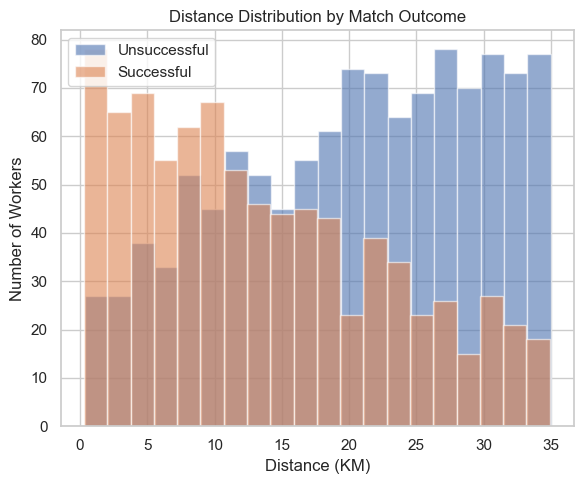

In [53]:
plt.figure(figsize=(6, 5))

for match_value, label in [(0, 'Unsuccessful'), (1, 'Successful')]:
    data = df[
        df['Is_Successful_Match'] == match_value
    ]['Distance_KM']

    plt.hist(
        data,
        bins=20,
        alpha=0.6,
        label=label
    )

plt.title('Distance Distribution by Match Outcome')
plt.xlabel('Distance (KM)')
plt.ylabel('Number of Workers')
plt.legend()

plt.tight_layout()
plt.show()

<Figure size 900x600 with 0 Axes>

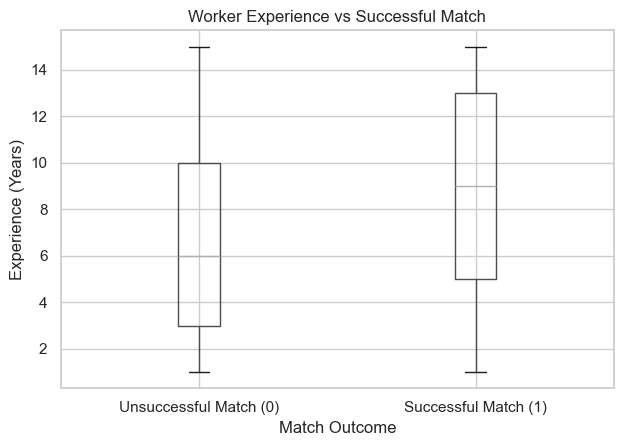

In [54]:
plt.figure(figsize=(9, 6))

df.boxplot(
    column='Worker_Experience_Years',
    by='Is_Successful_Match'
)

plt.title('Worker Experience vs Successful Match')
plt.suptitle('')
plt.xlabel('Match Outcome')
plt.ylabel('Experience (Years)')

plt.xticks(
    [1, 2],
    ['Unsuccessful Match (0)', 'Successful Match (1)']
)

plt.tight_layout()
plt.show()

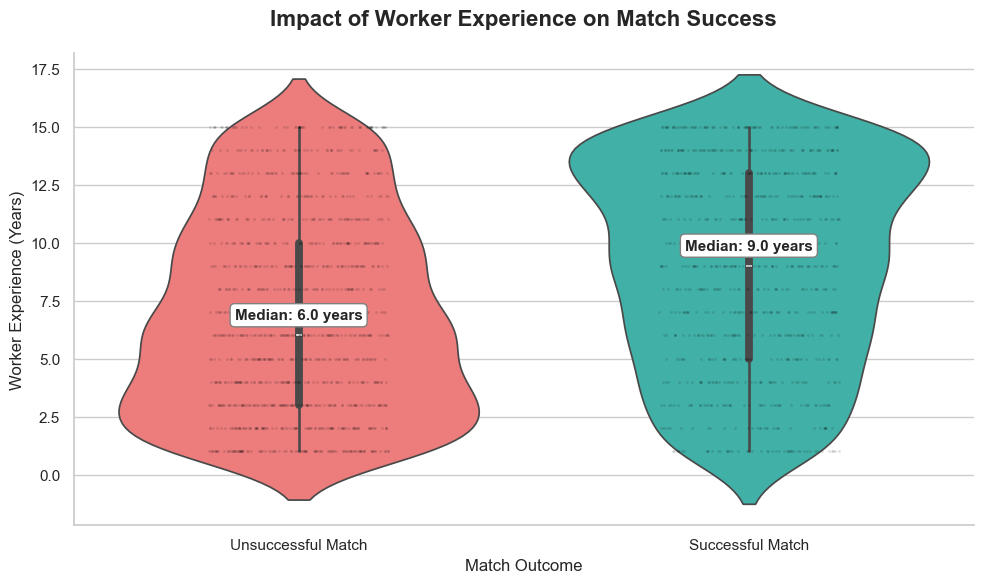

In [55]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Violin plot
ax = sns.violinplot(
    data=df,
    x="Is_Successful_Match",
    y="Worker_Experience_Years",
    hue="Is_Successful_Match",
    palette=["#FF6B6B", "#2EC4B6"],
    inner="box",
    legend=False
)

# Show individual observations
sns.stripplot(
    data=df,
    x="Is_Successful_Match",
    y="Worker_Experience_Years",
    color="black",
    alpha=0.12,
    jitter=0.2,
    size=2
)

# Calculate median values
medians = df.groupby(
    "Is_Successful_Match"
)["Worker_Experience_Years"].median()

# Display median labels
for i, median in enumerate(medians):
    ax.text(
        i, median + 0.7,
        f"Median: {median:.1f} years",
        ha="center",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            boxstyle="round,pad=0.3"
        )
    )

plt.xticks(
    [0, 1],
    ["Unsuccessful Match", "Successful Match"]
)

plt.title(
    "Impact of Worker Experience on Match Success",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Match Outcome", fontsize=12)
plt.ylabel("Worker Experience (Years)", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

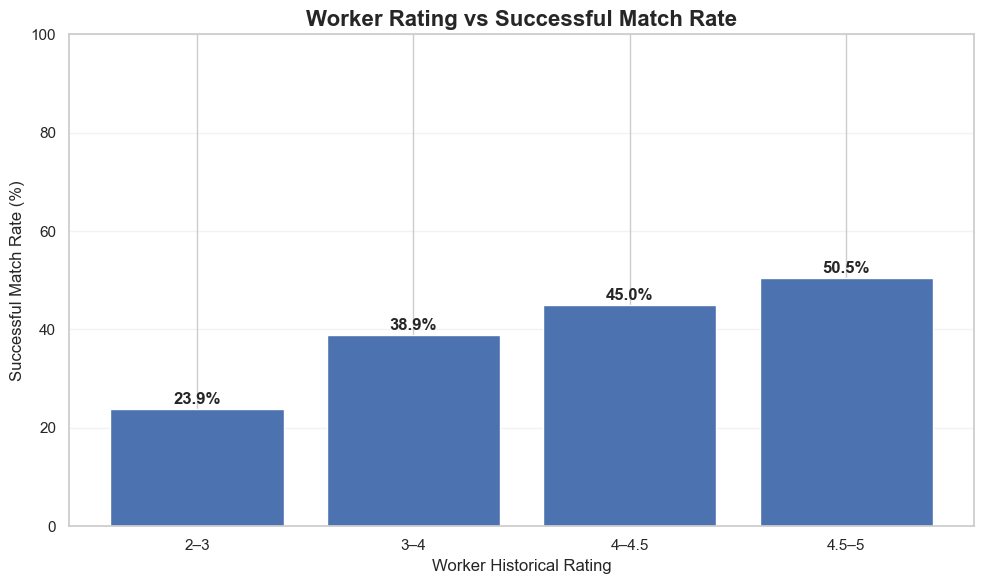

In [56]:
# Create rating bands
df['Rating_Band'] = pd.cut(
    df['Worker_Historical_Rating'],
    bins=[0, 2, 3, 4, 4.5, 5],
    labels=[
        '0–2',
        '2–3',
        '3–4',
        '4–4.5',
        '4.5–5'
    ],
    include_lowest=True
)

# Calculate successful match percentage for each rating band
rating_success = (
    df.groupby('Rating_Band', observed=True)['Is_Successful_Match']
    .mean()
    .mul(100)
    .reset_index(name='Success_Rate')
)

# Plot
plt.figure(figsize=(10, 6))

bars = plt.bar(
    rating_success['Rating_Band'].astype(str),
    rating_success['Success_Rate']
)

# Add percentage labels
for bar, value in zip(bars, rating_success['Success_Rate']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{value:.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.title(
    'Worker Rating vs Successful Match Rate',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Worker Historical Rating')
plt.ylabel('Successful Match Rate (%)')

plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

In [57]:
df.describe()

,Worker_Experience_Years,Distance_KM,Worker_Historical_Rating,Farmer_Historical_Rating,Historical_Acceptance_Rate,Is_Successful_Match
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000
mean,7.810500,17.42304,3.995500,4.197550,0.649745,0.426500
std,4.395253,9.93401,0.580007,0.466088,0.202028,0.494692
min,1.000000,0.30000,3.000000,3.400000,0.300000,0.000000
25%,4.000000,8.86500,3.500000,3.800000,0.470000,0.000000
50%,8.000000,17.37000,4.000000,4.200000,0.650000,0.000000
75%,12.000000,26.03500,4.500000,4.600000,0.830000,1.000000
max,15.000000,34.98000,5.000000,5.000000,1.000000,1.000000


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Worker_Experience_Years     2000 non-null   int64   
 1   Worker_Primary_Skills       2000 non-null   object  
 2   Job_Required_Skill          2000 non-null   object  
 3   Distance_KM                 2000 non-null   float64 
 4   Worker_Historical_Rating    2000 non-null   float64 
 5   Farmer_Historical_Rating    2000 non-null   float64 
 6   Historical_Acceptance_Rate  2000 non-null   float64 
 7   Is_Successful_Match         2000 non-null   int64   
 8   Rating_Band                 2000 non-null   category
dtypes: category(1), float64(4), int64(2), object(2)
memory usage: 127.3+ KB


### Job_Required_Skill → One-Hot Encoding

In [59]:
df.columns.tolist()

['Worker_Experience_Years',
 'Worker_Primary_Skills',
 'Job_Required_Skill',
 'Distance_KM',
 'Worker_Historical_Rating',
 'Farmer_Historical_Rating',
 'Historical_Acceptance_Rate',
 'Is_Successful_Match',
 'Rating_Band']

In [60]:
# One-Hot Encoding for Job_Required_Skill

job_skill_encoded = pd.get_dummies(
    df['Job_Required_Skill'],
    prefix='Required_Skill',
    dtype=int
)

print("✓ Job_Required_Skill encoded successfully!")

print("\nEncoded columns:")
print(job_skill_encoded.columns.tolist())

display(job_skill_encoded.head())

✓ Job_Required_Skill encoded successfully!

Encoded columns:
['Required_Skill_Harvesting', 'Required_Skill_Irrigation Setup', 'Required_Skill_Pesticide Spraying', 'Required_Skill_Pruning', 'Required_Skill_Seeding', 'Required_Skill_Tractor Driving']


,Required_Skill_Harvesting,Required_Skill_Irrigation Setup,Required_Skill_Pesticide Spraying,Required_Skill_Pruning,Required_Skill_Seeding,Required_Skill_Tractor Driving
0,0,0,0,1,0,0
1,0,0,0,0,1,0
2,1,0,0,0,0,0
3,1,0,0,0,0,0
4,0,0,1,0,0,0


In [61]:
# Remove original categorical column
df.drop(columns=['Job_Required_Skill'], inplace=True)

# Add encoded columns to df
df[job_skill_encoded.columns] = job_skill_encoded

print("✓ Job_Required_Skill replaced with One-Hot Encoded columns!")

display(df.head())

✓ Job_Required_Skill replaced with One-Hot Encoded columns!


,Worker_Experience_Years,Worker_Primary_Skills,Distance_KM,Worker_Historical_Rating,Farmer_Historical_Rating,Historical_Acceptance_Rate,Is_Successful_Match,Rating_Band,Required_Skill_Harvesting,Required_Skill_Irrigation Setup,Required_Skill_Pesticide Spraying,Required_Skill_Pruning,Required_Skill_Seeding,Required_Skill_Tractor Driving
0,10,"Seeding, Pesticide Spraying",33.98,4.1,3.9,0.66,0,4–4.5,0,0,0,1,0,0
1,1,"Pesticide Spraying, Harvesting, Seeding",19.70,4.0,3.6,0.61,1,3–4,0,0,0,0,1,0
2,13,"Pruning, Tractor Driving, Pesticide Spraying",17.08,3.6,3.8,0.32,0,3–4,1,0,0,0,0,0
3,1,"Seeding, Harvesting",2.14,4.5,4.9,0.47,1,4–4.5,1,0,0,0,0,0
4,9,"Seeding, Pesticide Spraying, Harvesting",14.30,4.4,3.7,0.87,1,4–4.5,0,0,1,0,0,0


In [62]:
# Multi-Label Encoding for Worker_Primary_Skills

worker_skills_encoded = df['Worker_Primary_Skills'].str.get_dummies(sep=',')

# Remove extra spaces from column names
worker_skills_encoded.columns = (
    worker_skills_encoded.columns.str.strip()
)

# Handle duplicate skill columns, if any
worker_skills_encoded = (
    worker_skills_encoded.T
    .groupby(level=0)
    .max()
    .T
)

print("✓ Worker_Primary_Skills encoded successfully!")

print("\nEncoded columns:")
print(worker_skills_encoded.columns.tolist())

display(worker_skills_encoded.head())

✓ Worker_Primary_Skills encoded successfully!

Encoded columns:
['Harvesting', 'Irrigation Setup', 'Pesticide Spraying', 'Pruning', 'Seeding', 'Tractor Driving']


,Harvesting,Irrigation Setup,Pesticide Spraying,Pruning,Seeding,Tractor Driving
0,0,0,1,0,1,0
1,1,0,1,0,1,0
2,0,0,1,1,0,1
3,1,0,0,0,1,0
4,1,0,1,0,1,0


In [63]:
# Remove original Worker_Primary_Skills column
df.drop(columns=['Worker_Primary_Skills'], inplace=True)

# Add multi-label encoded columns directly to df
df[worker_skills_encoded.columns] = worker_skills_encoded

print("✓ Original Worker_Primary_Skills removed!")
print("✓ Multi-label encoded columns added to df!")

display(df.head())

✓ Original Worker_Primary_Skills removed!
✓ Multi-label encoded columns added to df!


,Worker_Experience_Years,Distance_KM,Worker_Historical_Rating,Farmer_Historical_Rating,Historical_Acceptance_Rate,Is_Successful_Match,Rating_Band,Required_Skill_Harvesting,Required_Skill_Irrigation Setup,Required_Skill_Pesticide Spraying,Required_Skill_Pruning,Required_Skill_Seeding,Required_Skill_Tractor Driving,Harvesting,Irrigation Setup,Pesticide Spraying,Pruning,Seeding,Tractor Driving
0,10,33.98,4.1,3.9,0.66,0,4–4.5,0,0,0,1,0,0,0,0,1,0,1,0
1,1,19.70,4.0,3.6,0.61,1,3–4,0,0,0,0,1,0,1,0,1,0,1,0
2,13,17.08,3.6,3.8,0.32,0,3–4,1,0,0,0,0,0,0,0,1,1,0,1
3,1,2.14,4.5,4.9,0.47,1,4–4.5,1,0,0,0,0,0,1,0,0,0,1,0
4,9,14.30,4.4,3.7,0.87,1,4–4.5,0,0,1,0,0,0,1,0,1,0,1,0


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Worker_Experience_Years            2000 non-null   int64   
 1   Distance_KM                        2000 non-null   float64 
 2   Worker_Historical_Rating           2000 non-null   float64 
 3   Farmer_Historical_Rating           2000 non-null   float64 
 4   Historical_Acceptance_Rate         2000 non-null   float64 
 5   Is_Successful_Match                2000 non-null   int64   
 6   Rating_Band                        2000 non-null   category
 7   Required_Skill_Harvesting          2000 non-null   int64   
 8   Required_Skill_Irrigation Setup    2000 non-null   int64   
 9   Required_Skill_Pesticide Spraying  2000 non-null   int64   
 10  Required_Skill_Pruning             2000 non-null   int64   
 11  Required_Skill_Seeding             2000 non

In [65]:
from sklearn.preprocessing import StandardScaler

# Numerical features
numeric_features = [
    'Worker_Experience_Years',
    'Distance_KM',
    'Worker_Historical_Rating',
    'Farmer_Historical_Rating',
    'Historical_Acceptance_Rate'
]

# Create scaler
scaler = StandardScaler()

# Fit and transform numerical features
X_numeric_scaled = scaler.fit_transform(
    df[numeric_features]
)

print("✓ Numerical features scaled successfully!")

display(pd.DataFrame(
    X_numeric_scaled,
    columns=numeric_features
).head())

✓ Numerical features scaled successfully!


,Worker_Experience_Years,Distance_KM,Worker_Historical_Rating,Farmer_Historical_Rating,Historical_Acceptance_Rate
0,0.498276,1.667111,0.180215,-0.638559,0.050773
1,-1.549900,0.229266,0.007760,-1.282376,-0.196780
2,1.181001,-0.034541,-0.682059,-0.853165,-1.632585
3,-1.549900,-1.538841,0.870035,1.507497,-0.889927
4,0.270701,-0.314457,0.697580,-1.067770,1.090494


In [66]:
print(pd.DataFrame(
    X_numeric_scaled,
    columns=numeric_features
).describe())

       Worker_Experience_Years   Distance_KM  Worker_Historical_Rating  \
count             2.000000e+03  2.000000e+03              2.000000e+03   
mean             -7.371881e-17 -3.019807e-17              2.948752e-16   
std               1.000250e+00  1.000250e+00              1.000250e+00   
min              -1.549900e+00 -1.724110e+00             -1.716788e+00   
25%              -8.671749e-01 -8.617044e-01             -8.545139e-01   
50%               4.312548e-02 -5.340569e-03              7.760469e-03   
75%               9.534258e-01  8.671336e-01              8.700348e-01   
max               1.636151e+00  1.767801e+00              1.732309e+00   

       Farmer_Historical_Rating  Historical_Acceptance_Rate  
count              2.000000e+03                2.000000e+03  
mean               6.963319e-16               -8.082424e-17  
std                1.000250e+00                1.000250e+00  
min               -1.711587e+00               -1.731606e+00  
25%               -8.53

In [67]:
#Keep ORIGINAL raw columns for training
X = df.drop(columns=["Is_Successful_Match"])
y = df["Is_Successful_Match"]

In [68]:
from sklearn.model_selection import train_test_split
#  Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [69]:
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
# Feature groups must match the already-encoded dataframe built earlier.
numeric_features = [
    "Worker_Experience_Years",
    "Distance_KM",
    "Worker_Historical_Rating",
    "Farmer_Historical_Rating",
    "Historical_Acceptance_Rate"
]

encoded_features = [
    col for col in X.columns
    if col not in numeric_features and col != "Is_Successful_Match"
]

In [ ]:
# Scale numeric features while keeping the already-encoded skill columns.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("encoded", "passthrough", encoded_features)
    ],
    remainder="drop"
)

In [ ]:
# Keep this cell only as a sanity check; the encoded skill columns are already numeric.
print("Encoded feature count:", len(encoded_features))
print(encoded_features[:5])

In [ ]:
# This custom encoder is no longer needed because the skill columns were already expanded earlier.
pass

In [ ]:
# Combine the numeric scaling and passthrough encoded features.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("encoded", "passthrough", encoded_features)
    ],
    remainder="drop"
)

In [77]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [78]:
#  Candidate models
candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

In [ ]:
# Cell 18: visualize pipeline
from sklearn import set_config
set_config(display="diagram")
best_pipeline

In [ ]:
# Cell 19: feature count by block
preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
feature_names = preprocessor.get_feature_names_out()

numeric_names = [n for n in feature_names if n.startswith("num__")]
encoded_names = [n for n in feature_names if n.startswith("encoded__")]

print("Numeric features:", len(numeric_names))
print("Encoded skill features:", len(encoded_names))

parts = {
    "Numeric": len(numeric_names),
    "Encoded skill columns": len(encoded_names)
}

plt.figure(figsize=(8, 5))
plt.bar(parts.keys(), parts.values(), color=["#4C72B0", "#55A868"])
plt.title("Feature Count After Preprocessing")
plt.ylabel("Number of Features")
plt.tight_layout()
plt.show()